# Assignment 7 - Logistic Regression (Diabetes Dataset)

This notebook performs binary classification using Logistic Regression on `Datasets/diabetes2.csv`.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
)

In [18]:
df = pd.read_csv('../../Datasets/diabetes2.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
df.shape

(768, 9)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [21]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


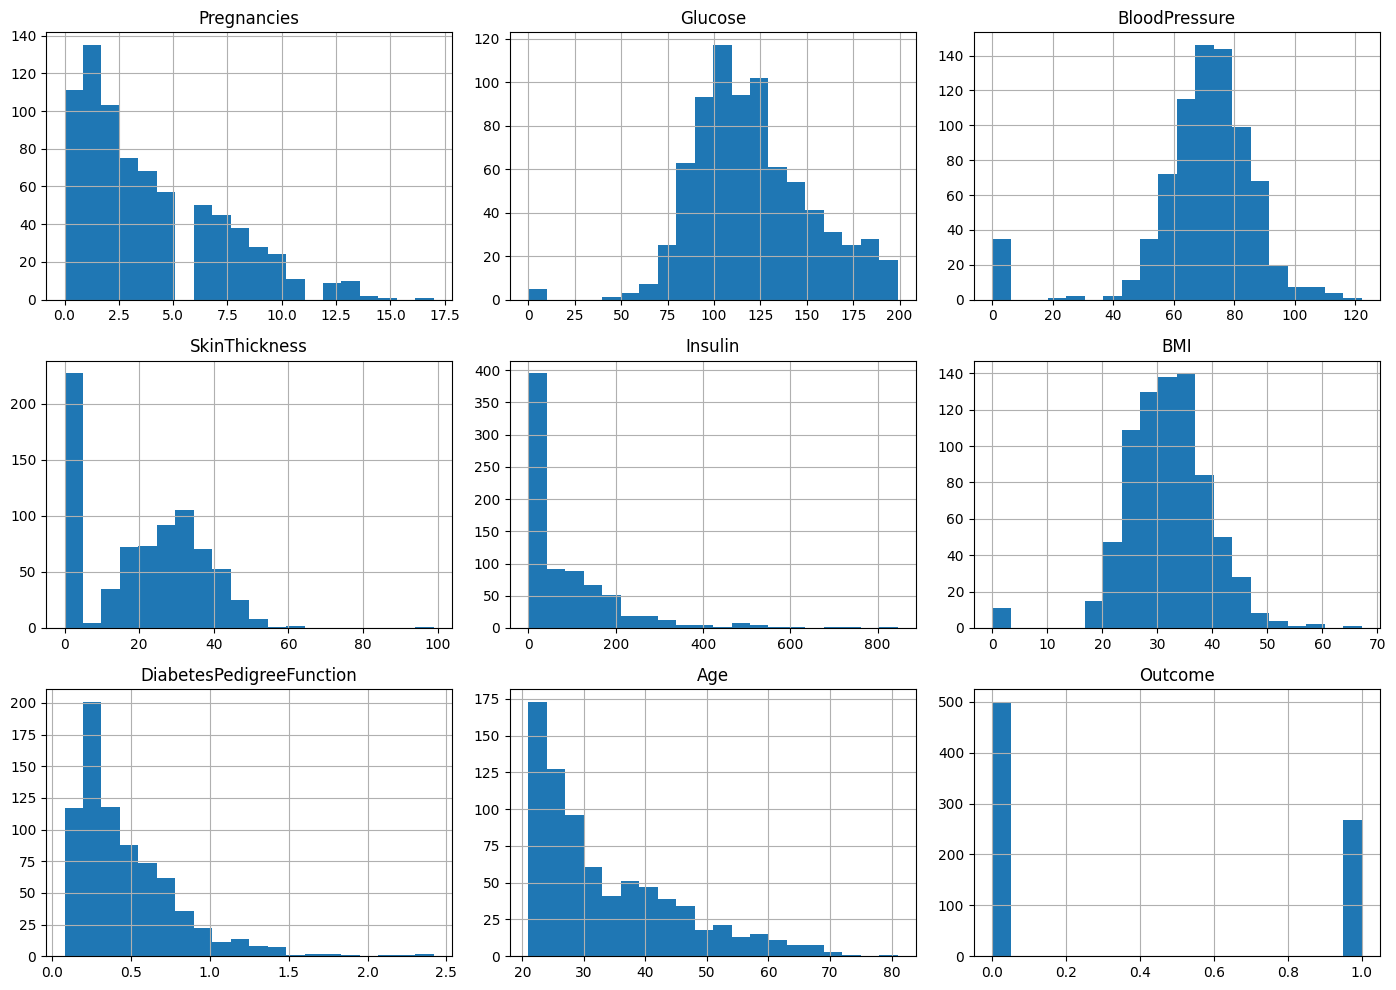

In [22]:
df.hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

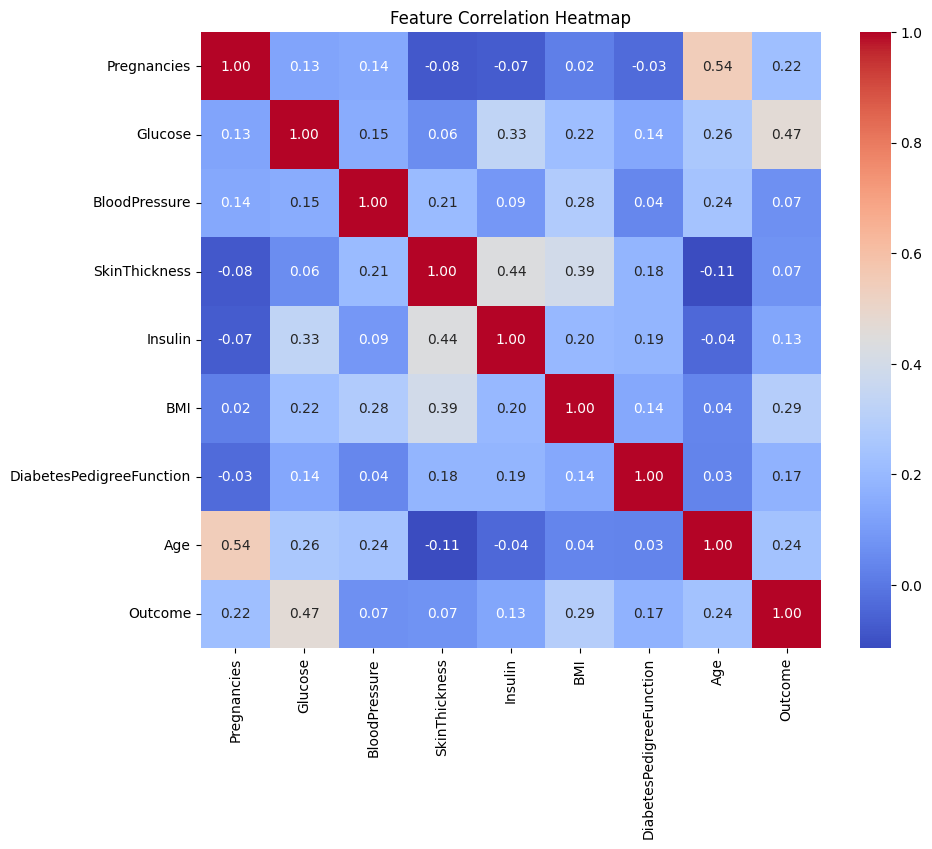

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [31]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=105, stratify=y
)

In [33]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
import warnings

warnings.filterwarnings(
    'ignore',
    category=FutureWarning,
    message=r".*'penalty' was deprecated.*"
 )
warnings.filterwarnings(
    'ignore',
    category=UserWarning,
    message=r".*Inconsistent values: penalty=l1 with l1_ratio=0.0.*"
 )

lr = LogisticRegression()

parameter = [
    {'penalty': ['l1'], 'solver': ['liblinear', 'saga'], 'C': [1, 2, 3, 4, 5], 'max_iter': [1000]},
    {'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear', 'saga'], 'C': [1, 2, 3, 4, 5], 'max_iter': [1000]},
    {'penalty': ['elasticnet'], 'solver': ['saga'], 'l1_ratio': [0.5], 'C': [1, 2, 3, 4, 5], 'max_iter': [1000]}
]

grid = GridSearchCV(lr, param_grid=parameter, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print('Best Parameters:', grid.best_params_)
print('Best CV Score:', grid.best_score_)

Best Parameters: {'C': 2, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.7708695652173913


In [36]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('Accuracy :', accuracy)
print('Precision:', precision)
print('Recall   :', recall)
print('F1 Score :', f1)
print('ROC AUC  :', roc_auc)

Accuracy : 0.7864583333333334
Precision: 0.75
Recall   : 0.582089552238806
F1 Score : 0.6554621848739496
ROC AUC  : 0.8653134328358209


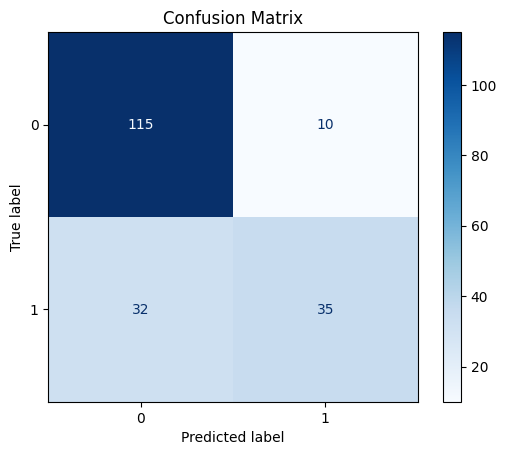

In [29]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

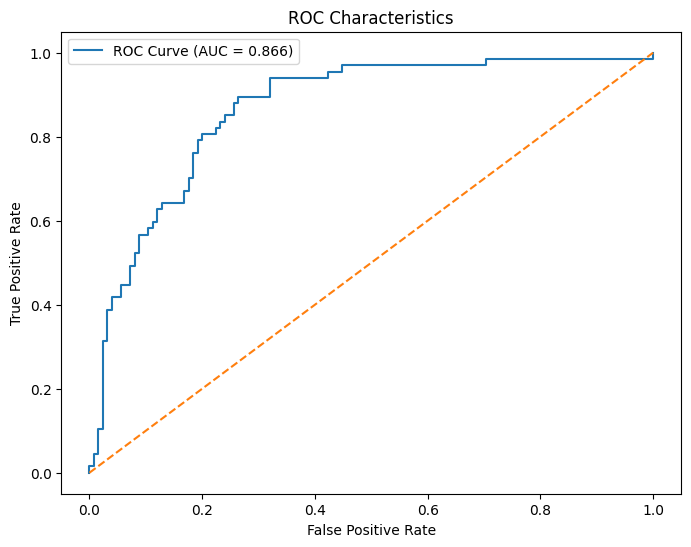

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Characteristics')
plt.legend()
plt.show()